# Laboratório 1 — Sistemas com atrasos de transporte

Disciplina: Introdução aos Sistemas de Controle

Aluno 1: Inácio Rodrigues de Matos Galvão — Matrícula: 485178

Aluno 2: Nome — Matrícula: 

---

## 1. Introdução

O atraso de transporte aparece como um termo $e^{-\theta s}$ na função de transferência. Esse termo não é um polinômio, então não dá para extrair polos e zeros diretamente dele. A saída é usar a aproximação de Padé, que troca $e^{-\theta s}$ por uma fração racional — aí sim podemos trabalhar com as ferramentas de controle.

Aqui comparamos aproximações de 1ª, 2ª e 3ª ordem com o atraso puro, usando Python.

## 2. Descrição do sistema

O sistema é um tanque com agitação aquecido por resistência elétrica. O balanço de energia dá:

$$\frac{V}{F} \frac{dT(t)}{dt} + T(t) = T_i(t) + \frac{1}{\rho C_p F} P(t)$$

A medição de temperatura acontece a uma distância $d$ do tanque, o que gera um atraso:

$$T_2(t) = T(t - \theta), \qquad \theta = \frac{A \cdot d}{F}$$

No diagrama de blocos, temos duas funções de transferência:

$$G_1(s) = \frac{k_1}{\tau_1 s + 1} \qquad G_2(s) = \frac{k_2 \, e^{-\theta s}}{\tau_2 s + 1}$$

$G_1(s)$ é a fonte de tensão, $G_2(s)$ é o processo térmico com o atraso embutido.

## 3. Parâmetros do sistema

Valores do enunciado:

| Parâmetro | Valor | O que é |
|-----------|-------|---------|
| $k_1$ | 2 | Ganho da fonte de tensão |
| $\tau_1$ | 0,25 s | Constante de tempo elétrica |
| $k_2$ | 1 | Ganho do processo térmico |
| $\tau_2$ | 1 s | Constante de tempo do processo |
| $\theta$ | 1 s | Atraso de transporte (análise inicial) |

In [ ]:
# Instala as dependências (execute apenas uma vez)
%pip install -q control numpy matplotlib scipy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
from scipy.signal import lti, step

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['grid.alpha'] = 0.3

# Função para imprimir a FT de forma limpa (só a fração)
def print_tf(name, sys):
    """Imprime só o numerador/denominador, sem metadados."""
    s = str(sys)
    lines = s.strip().split('\n')
    frac_lines = [l for l in lines if not l.startswith('<') and not l.startswith('Inputs') and not l.startswith('Outputs')]
    print(f"{name}")
    print('\n'.join(frac_lines))
    print()

# ==================== Parâmetros do sistema ====================
k1 = 2          # Ganho da fonte de tensão
tau1 = 0.25     # Constante de tempo elétrica [s]
k2 = 1          # Ganho do processo térmico
tau2 = 1        # Constante de tempo do processo [s]
theta = 1       # Atraso de transporte [s]

print("Parâmetros definidos:")
print(f"  k1 = {k1}, τ1 = {tau1} s")
print(f"  k2 = {k2}, τ2 = {tau2} s")
print(f"  θ  = {theta} s")

Parâmetros definidos:
  k1 = 2, τ1 = 0.25 s
  k2 = 1, τ2 = 1 s
  θ  = 1 s


## 4. Funções de transferência

Substituindo os parâmetros:

$$G_1(s) = \frac{2}{0{,}25s + 1} \qquad G_2(s) = \frac{e^{-\theta s}}{s + 1}$$

Em malha aberta, sem atraso:

$$G_{MA}(s) = G_1(s) \cdot G_{2,\text{sem atraso}}(s) = \frac{2}{(0{,}25s + 1)(s + 1)}$$

No código abaixo montamos essas FTs e conferimos polos, zeros e ganho DC.

In [2]:
# ==================== Funções de transferência ====================

# G1(s) = k1 / (tau1*s + 1)
G1 = ctrl.tf([k1], [tau1, 1])
print_tf("G1(s) - Fonte de tensão:", G1)

# G2 sem atraso: G2_sa(s) = k2 / (tau2*s + 1)
G2_sa = ctrl.tf([k2], [tau2, 1])
print_tf("G2(s) sem atraso:", G2_sa)

# Sistema completo em malha aberta (sem atraso)
G_ma_sem_atraso = ctrl.series(G1, G2_sa)
print_tf("G_MA(s) = G1(s) · G2(s) sem atraso:", G_ma_sem_atraso)

print(f"Polos: {G_ma_sem_atraso.poles()}")
print(f"Zeros: {G_ma_sem_atraso.zeros()}")
print(f"Ganho DC: {ctrl.dcgain(G_ma_sem_atraso)}")

G1(s) - Fonte de tensão:

      2
  ----------
  0.25 s + 1

G2(s) sem atraso:

    1
  -----
  s + 1

G_MA(s) = G1(s) · G2(s) sem atraso:

            2
  ---------------------
  0.25 s^2 + 1.25 s + 1

Polos: [-4.+0.j -1.+0.j]
Zeros: []
Ganho DC: 2.0


## 5. Aproximações de Padé

A aproximação de Padé $[n/n]$ troca $e^{-\theta s}$ por uma razão de polinômios de grau $n$. Quanto maior a ordem, melhor a aproximação.

Usamos duas implementações: uma montando os coeficientes manualmente e outra pela função `control.pade()` (equivalente à `pade` do MATLAB). As duas devem dar o mesmo resultado.

In [3]:
# ==================== Aproximações de Padé — Implementação Manual ====================
# Para theta = 1 s

# --- Padé 1ª Ordem [1/1] ---
# e^(-θs) ≈ (2 - θs) / (2 + θs)
num_pade1_manual = [-theta, 2]        # -θs + 2
den_pade1_manual = [theta, 2]         #  θs + 2
Pade1_manual = ctrl.tf(num_pade1_manual, den_pade1_manual)

print("="*50)
print("Padé 1ª Ordem [1/1] — Manual")
print("="*50)
print_tf("", Pade1_manual)
print(f"Polos: {Pade1_manual.poles()}")
print(f"Zeros: {Pade1_manual.zeros()}")
print(f"Ganho DC: {ctrl.dcgain(Pade1_manual):.4f}")

# --- Padé 2ª Ordem [2/2] ---
# e^(-θs) ≈ (θ²s² - 6θs + 12) / (θ²s² + 6θs + 12)
num_pade2_manual = [theta**2, -6*theta, 12]
den_pade2_manual = [theta**2, 6*theta, 12]
Pade2_manual = ctrl.tf(num_pade2_manual, den_pade2_manual)

print("\n" + "="*50)
print("Padé 2ª Ordem [2/2] — Manual")
print("="*50)
print_tf("", Pade2_manual)
print(f"Polos: {Pade2_manual.poles()}")
print(f"Zeros: {Pade2_manual.zeros()}")
print(f"Ganho DC: {ctrl.dcgain(Pade2_manual):.4f}")

# --- Padé 3ª Ordem [3/3] ---
# e^(-θs) ≈ (-θ³s³ + 12θ²s² - 60θs + 120) / (θ³s³ + 12θ²s² + 60θs + 120)
num_pade3_manual = [-theta**3, 12*theta**2, -60*theta, 120]
den_pade3_manual = [theta**3, 12*theta**2, 60*theta, 120]
Pade3_manual = ctrl.tf(num_pade3_manual, den_pade3_manual)

print("\n" + "="*50)
print("Padé 3ª Ordem [3/3] — Manual")
print("="*50)
print_tf("", Pade3_manual)
print(f"Polos: {Pade3_manual.poles()}")
print(f"Zeros: {Pade3_manual.zeros()}")
print(f"Ganho DC: {ctrl.dcgain(Pade3_manual):.4f}")

Padé 1ª Ordem [1/1] — Manual


  -s + 2
  ------
  s + 2

Polos: [-2.+0.j]
Zeros: [2.+0.j]
Ganho DC: 1.0000

Padé 2ª Ordem [2/2] — Manual


  s^2 - 6 s + 12
  --------------
  s^2 + 6 s + 12

Polos: [-3.+1.73205081j -3.-1.73205081j]
Zeros: [3.+1.73205081j 3.-1.73205081j]
Ganho DC: 1.0000

Padé 3ª Ordem [3/3] — Manual


  -s^3 + 12 s^2 - 60 s + 120
  --------------------------
  s^3 + 12 s^2 + 60 s + 120

Polos: [-3.67781465+3.50876192j -3.67781465-3.50876192j -4.64437071+0.j        ]
Zeros: [3.67781465+3.50876192j 3.67781465-3.50876192j 4.64437071+0.j        ]
Ganho DC: 1.0000


In [4]:
# ==================== Aproximações de Padé — Função control.pade ====================
# A função control.pade(T, n) retorna (num, den) da aproximação de ordem n para e^(-Ts)

# --- Padé 1ª Ordem ---
num_p1, den_p1 = ctrl.pade(theta, 1)
Pade1_ctrl = ctrl.tf(num_p1, den_p1)

print("="*50)
print("Padé 1ª Ordem [1/1] — control.pade")
print("="*50)
print_tf("", Pade1_ctrl)

# --- Padé 2ª Ordem ---
num_p2, den_p2 = ctrl.pade(theta, 2)
Pade2_ctrl = ctrl.tf(num_p2, den_p2)

print("="*50)
print("Padé 2ª Ordem [2/2] — control.pade")
print("="*50)
print_tf("", Pade2_ctrl)

# --- Padé 3ª Ordem ---
num_p3, den_p3 = ctrl.pade(theta, 3)
Pade3_ctrl = ctrl.tf(num_p3, den_p3)

print("="*50)
print("Padé 3ª Ordem [3/3] — control.pade")
print("="*50)
print_tf("", Pade3_ctrl)

# --- Verificação: as implementações manual e control.pade devem ser equivalentes ---
print("="*50)
print("Verificação: Polos e Zeros coincidem?")
print("="*50)
for n, (manual, auto) in enumerate([(Pade1_manual, Pade1_ctrl),
                                     (Pade2_manual, Pade2_ctrl),
                                     (Pade3_manual, Pade3_ctrl)], 1):
    polos_ok = np.allclose(sorted(manual.poles()), sorted(auto.poles()))
    zeros_ok = np.allclose(sorted(manual.zeros()), sorted(auto.zeros()))
    print(f"  Ordem {n}: Polos {'✓' if polos_ok else '✗'} | Zeros {'✓' if zeros_ok else '✗'}")

Padé 1ª Ordem [1/1] — control.pade


  -s + 2
  ------
  s + 2

Padé 2ª Ordem [2/2] — control.pade


  s^2 - 6 s + 12
  --------------
  s^2 + 6 s + 12

Padé 3ª Ordem [3/3] — control.pade


  -s^3 + 12 s^2 - 60 s + 120
  --------------------------
  s^3 + 12 s^2 + 60 s + 120

Verificação: Polos e Zeros coincidem?
  Ordem 1: Polos ✓ | Zeros ✓
  Ordem 2: Polos ✓ | Zeros ✓
  Ordem 3: Polos ✓ | Zeros ✓


## 6. Resposta ao degrau — Padé vs atraso puro

O atraso puro ideal simplesmente desloca o degrau por $\theta$ segundos: $y(t) = u(t - \theta)$.

Aqui comparamos esse comportamento com as três ordens de Padé para ver onde cada uma acerta e onde erra.

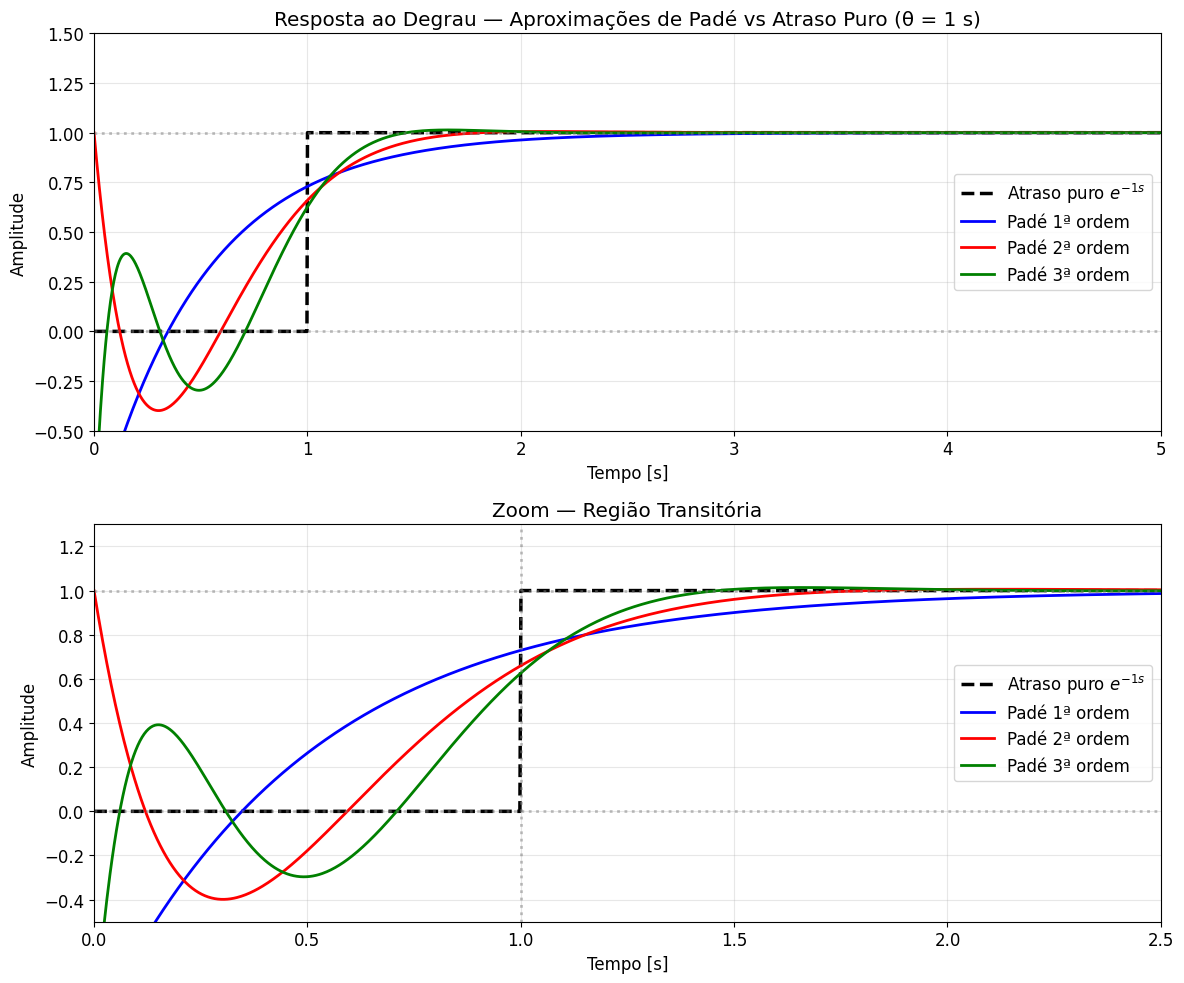

Observações:
  - Ordens ímpares (1ª, 3ª) apresentam undershoot inicial (valor negativo)
  - Ordens pares (2ª) apresentam overshoot inicial
  - Maior ordem → melhor aproximação do atraso puro


In [5]:
# ==================== Resposta ao degrau das aproximações de Padé ====================

t = np.linspace(0, 5, 2000)

# Resposta ao degrau de cada aproximação
t1, y1 = ctrl.step_response(Pade1_ctrl, t)
t2, y2 = ctrl.step_response(Pade2_ctrl, t)
t3, y3 = ctrl.step_response(Pade3_ctrl, t)

# Atraso puro ideal (degrau deslocado)
y_ideal = np.where(t >= theta, 1.0, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Gráfico completo ---
ax = axes[0]
ax.plot(t, y_ideal, 'k--', linewidth=2.5, label=f'Atraso puro $e^{{-{theta}s}}$')
ax.plot(t1, y1, 'b-', label='Padé 1ª ordem')
ax.plot(t2, y2, 'r-', label='Padé 2ª ordem')
ax.plot(t3, y3, 'g-', label='Padé 3ª ordem')
ax.set_xlabel('Tempo [s]')
ax.set_ylabel('Amplitude')
ax.set_title(f'Resposta ao Degrau — Aproximações de Padé vs Atraso Puro (θ = {theta} s)')
ax.legend(loc='best')
ax.grid(True)
ax.set_xlim([0, 5])
ax.set_ylim([-0.5, 1.5])
ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

# --- Zoom no transitório ---
ax = axes[1]
ax.plot(t, y_ideal, 'k--', linewidth=2.5, label=f'Atraso puro $e^{{-{theta}s}}$')
ax.plot(t1, y1, 'b-', label='Padé 1ª ordem')
ax.plot(t2, y2, 'r-', label='Padé 2ª ordem')
ax.plot(t3, y3, 'g-', label='Padé 3ª ordem')
ax.set_xlabel('Tempo [s]')
ax.set_ylabel('Amplitude')
ax.set_title('Zoom — Região Transitória')
ax.legend(loc='best')
ax.grid(True)
ax.set_xlim([0, 2.5])
ax.set_ylim([-0.5, 1.3])
ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=theta, color='gray', linestyle=':', alpha=0.5, label=f'θ = {theta} s')

plt.tight_layout()
plt.savefig('figuras/pade_aproximacoes_degrau.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observações:")
print("  - Ordens ímpares (1ª, 3ª) apresentam undershoot inicial (valor negativo)")
print("  - Ordens pares (2ª) apresentam overshoot inicial")
print("  - Maior ordem → melhor aproximação do atraso puro")

## 7. Mapa de polos e zeros

Mapa de polos e zeros de cada aproximação de Padé no plano complexo. A ideia é ver a simetria entre polos (SPE) e zeros (SPD) que é característica dessas aproximações.

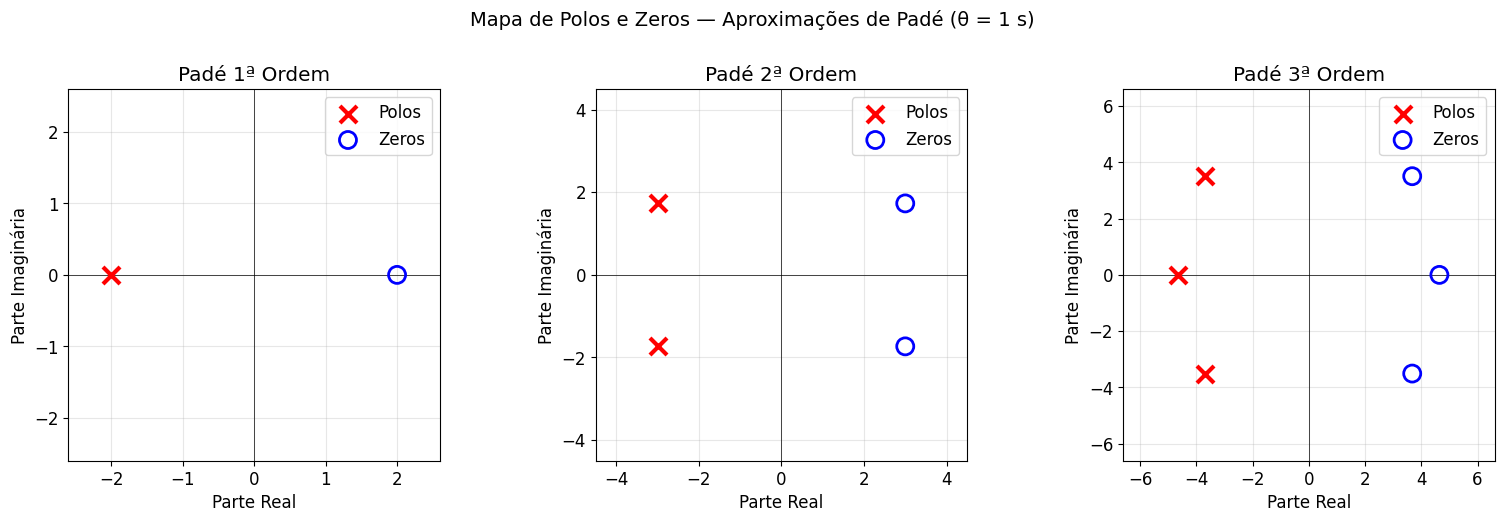

Nota: Os zeros (○) no semiplano direito são responsáveis pelo comportamento
de fase não-mínima (undershoot/overshoot inicial) das aproximações.


In [6]:
# ==================== Mapa de Polos e Zeros ====================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Padé 1ª Ordem', 'Padé 2ª Ordem', 'Padé 3ª Ordem']
systems = [Pade1_ctrl, Pade2_ctrl, Pade3_ctrl]

for ax, sys, title in zip(axes, systems, titles):
    poles = sys.poles()
    zeros = sys.zeros()

    ax.scatter(poles.real, poles.imag, marker='x', color='red', s=150, linewidths=3, label='Polos', zorder=5)
    ax.scatter(zeros.real, zeros.imag, marker='o', facecolors='none', edgecolors='blue', s=150, linewidths=2, label='Zeros', zorder=5)

    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_xlabel('Parte Real')
    ax.set_ylabel('Parte Imaginária')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    # Ajuste de limites simétrico
    max_val = max(np.max(np.abs(poles)), np.max(np.abs(zeros))) * 1.3
    ax.set_xlim([-max_val, max_val])
    ax.set_ylim([-max_val, max_val])

plt.suptitle(f'Mapa de Polos e Zeros — Aproximações de Padé (θ = {theta} s)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figuras/pade_polos_zeros.png', dpi=150, bbox_inches='tight')
plt.show()

print("Nota: Os zeros (○) no semiplano direito são responsáveis pelo comportamento")
print("de fase não-mínima (undershoot/overshoot inicial) das aproximações.")

## 8. Sistema completo em malha aberta (θ = 1 s)

Agora juntamos tudo: $G_1(s) \cdot G_2(s)$, com o atraso aproximado por Padé. Comparamos com a resposta ideal (sem atraso, deslocada por θ).

In [7]:
# ==================== Sistema completo em Malha Aberta ====================

# Sistema sem atraso
G_sem_atraso = ctrl.series(G1, G2_sa)

# Sistemas com aproximações de Padé
G_pade1 = ctrl.series(G1, G2_sa, Pade1_ctrl)
G_pade2 = ctrl.series(G1, G2_sa, Pade2_ctrl)
G_pade3 = ctrl.series(G1, G2_sa, Pade3_ctrl)

print("Sistema completo com Padé 1ª ordem:")
print_tf("", G_pade1)
print(f"Polos: {G_pade1.poles()}")
print(f"Zeros: {G_pade1.zeros()}")
print(f"Ganho DC: {ctrl.dcgain(G_pade1):.4f}")

Sistema completo com Padé 1ª ordem:


             -2 s + 4
  -------------------------------
  0.25 s^3 + 1.75 s^2 + 3.5 s + 2

Polos: [-4.+0.j -2.+0.j -1.+0.j]
Zeros: [2.+0.j]
Ganho DC: 2.0000


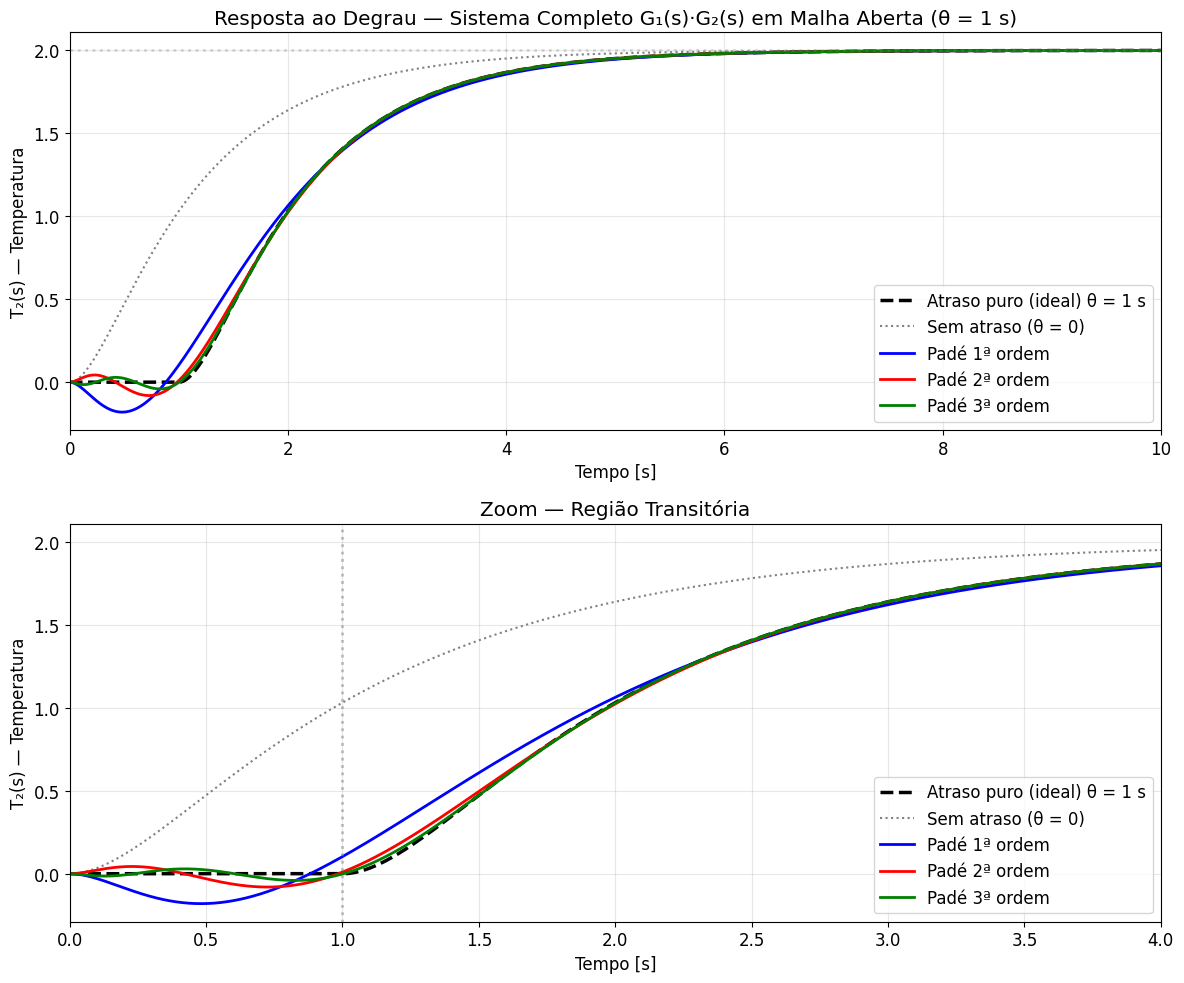

Ganho DC (valor final): 2.00
O atraso de transporte NÃO altera o valor final, apenas desloca a resposta no tempo.


In [8]:
# ==================== Resposta ao degrau — Sistema completo ====================

t = np.linspace(0, 10, 3000)

# Respostas com Padé
t_p1, y_p1 = ctrl.step_response(G_pade1, t)
t_p2, y_p2 = ctrl.step_response(G_pade2, t)
t_p3, y_p3 = ctrl.step_response(G_pade3, t)

# Resposta sem atraso
t_sa, y_sa = ctrl.step_response(G_sem_atraso, t)

# Resposta ideal (sem atraso deslocada por θ)
# Interpolamos a resposta sem atraso e deslocamos
y_ideal_sistema = np.where(t >= theta, np.interp(t - theta, t_sa, y_sa), 0.0)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Gráfico principal ---
ax = axes[0]
ax.plot(t, y_ideal_sistema, 'k--', linewidth=2.5, label=f'Atraso puro (ideal) θ = {theta} s')
ax.plot(t_sa, y_sa, 'gray', linestyle=':', linewidth=1.5, label='Sem atraso (θ = 0)')
ax.plot(t_p1, y_p1, 'b-', label='Padé 1ª ordem')
ax.plot(t_p2, y_p2, 'r-', label='Padé 2ª ordem')
ax.plot(t_p3, y_p3, 'g-', label='Padé 3ª ordem')
ax.set_xlabel('Tempo [s]')
ax.set_ylabel('T₂(s) — Temperatura')
ax.set_title(f'Resposta ao Degrau — Sistema Completo G₁(s)·G₂(s) em Malha Aberta (θ = {theta} s)')
ax.legend(loc='best')
ax.grid(True)
ax.set_xlim([0, 10])
ax.axhline(y=ctrl.dcgain(G_sem_atraso), color='gray', linestyle=':', alpha=0.3)

# --- Zoom no transitório ---
ax = axes[1]
ax.plot(t, y_ideal_sistema, 'k--', linewidth=2.5, label=f'Atraso puro (ideal) θ = {theta} s')
ax.plot(t_sa, y_sa, 'gray', linestyle=':', linewidth=1.5, label='Sem atraso (θ = 0)')
ax.plot(t_p1, y_p1, 'b-', label='Padé 1ª ordem')
ax.plot(t_p2, y_p2, 'r-', label='Padé 2ª ordem')
ax.plot(t_p3, y_p3, 'g-', label='Padé 3ª ordem')
ax.set_xlabel('Tempo [s]')
ax.set_ylabel('T₂(s) — Temperatura')
ax.set_title('Zoom — Região Transitória')
ax.legend(loc='best')
ax.grid(True)
ax.set_xlim([0, 4])
ax.axvline(x=theta, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('figuras/sistema_completo_degrau.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Ganho DC (valor final): {ctrl.dcgain(G_sem_atraso):.2f}")
print(f"O atraso de transporte NÃO altera o valor final, apenas desloca a resposta no tempo.")

## 9. Variação de θ em $[0,\ 2\tau_2]$

O enunciado diz que $\theta$ pode ir de 0 a $2\tau_2 = 2$ s. Varremos esse intervalo para ver como o atraso muda a resposta ao degrau.

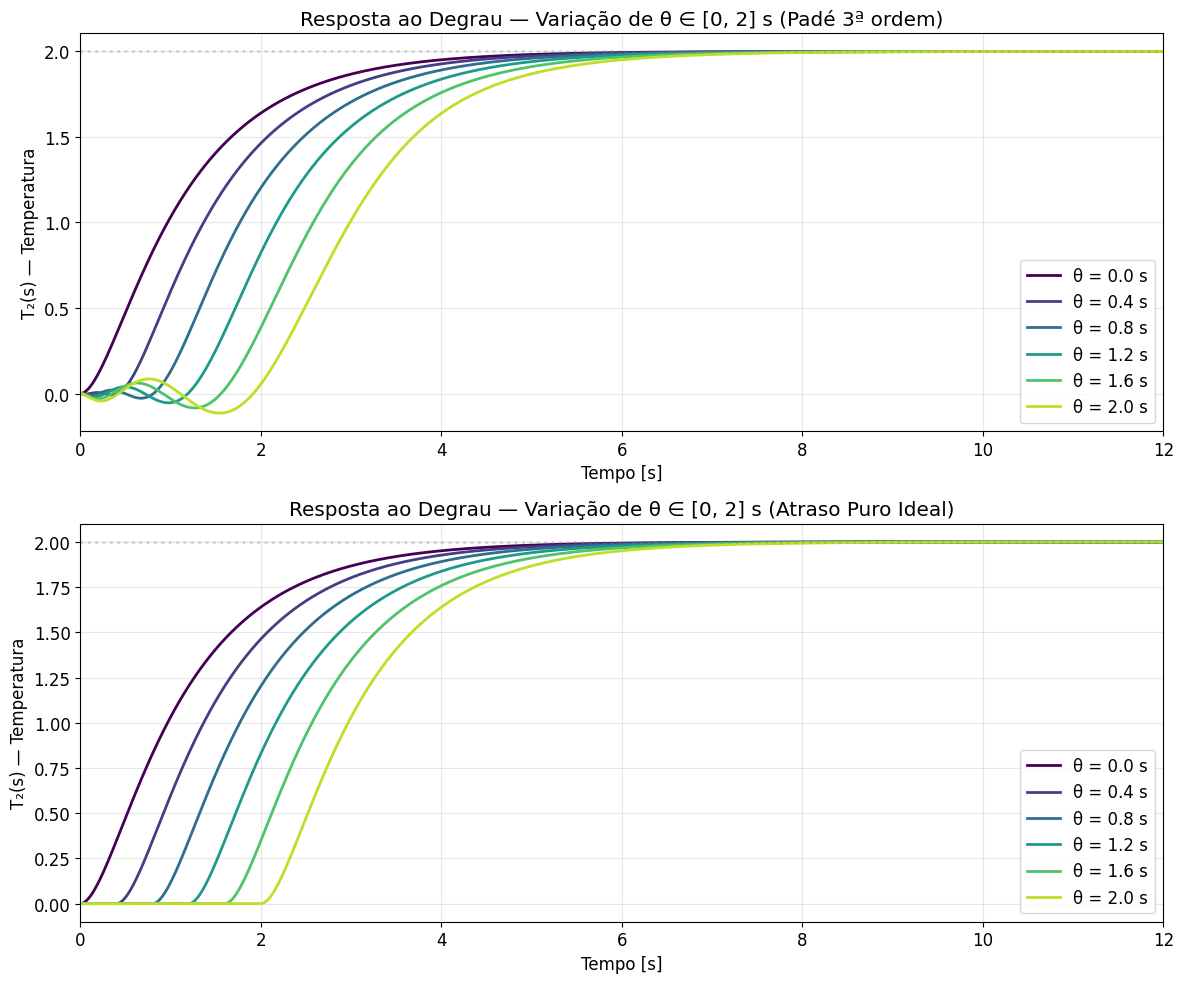

Observações:
  - Valor final (ganho DC) = 2.00 para todos os valores de θ
  - O atraso apenas desloca a resposta no tempo, sem alterar a dinâmica
  - Quanto maior θ, maior o tempo para o sistema começar a responder
  - Em malha fechada, atrasos maiores → maior dificuldade de controle


In [9]:
# ==================== Variação de θ no intervalo [0, 2τ₂] ====================

theta_values = np.linspace(0, 2*tau2, 6)  # θ = 0, 0.4, 0.8, 1.2, 1.6, 2.0
t = np.linspace(0, 12, 3000)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(theta_values)))

# --- Usando Padé 3ª ordem ---
ax = axes[0]
for th, color in zip(theta_values, colors):
    if th == 0:
        G_total = ctrl.series(G1, G2_sa)
    else:
        num_p, den_p = ctrl.pade(th, 3)
        Pade_approx = ctrl.tf(num_p, den_p)
        G_total = ctrl.series(G1, G2_sa, Pade_approx)

    t_r, y_r = ctrl.step_response(G_total, t)
    ax.plot(t_r, y_r, color=color, linewidth=2, label=f'θ = {th:.1f} s')

ax.set_xlabel('Tempo [s]')
ax.set_ylabel('T₂(s) — Temperatura')
ax.set_title(f'Resposta ao Degrau — Variação de θ ∈ [0, {2*tau2}] s (Padé 3ª ordem)')
ax.legend(loc='best')
ax.grid(True)
ax.set_xlim([0, 12])
ax.axhline(y=ctrl.dcgain(G_sem_atraso), color='gray', linestyle=':', alpha=0.3)

# --- Usando atraso puro (ideal) ---
ax = axes[1]
t_sa_ref, y_sa_ref = ctrl.step_response(G_sem_atraso, t)

for th, color in zip(theta_values, colors):
    y_shifted = np.where(t >= th, np.interp(t - th, t_sa_ref, y_sa_ref), 0.0)
    ax.plot(t, y_shifted, color=color, linewidth=2, label=f'θ = {th:.1f} s')

ax.set_xlabel('Tempo [s]')
ax.set_ylabel('T₂(s) — Temperatura')
ax.set_title(f'Resposta ao Degrau — Variação de θ ∈ [0, {2*tau2}] s (Atraso Puro Ideal)')
ax.legend(loc='best')
ax.grid(True)
ax.set_xlim([0, 12])
ax.axhline(y=ctrl.dcgain(G_sem_atraso), color='gray', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig('figuras/variacao_theta.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observações:")
print(f"  - Valor final (ganho DC) = {ctrl.dcgain(G_sem_atraso):.2f} para todos os valores de θ")
print("  - O atraso apenas desloca a resposta no tempo, sem alterar a dinâmica")
print("  - Quanto maior θ, maior o tempo para o sistema começar a responder")
print("  - Em malha fechada, atrasos maiores → maior dificuldade de controle")

## 10. Diagrama de Bode

O atraso puro tem magnitude constante ($|e^{-j\omega\theta}| = 1$) e fase que cai linearmente ($\angle = -\omega\theta$). Comparamos com o que cada ordem de Padé produz em frequência.

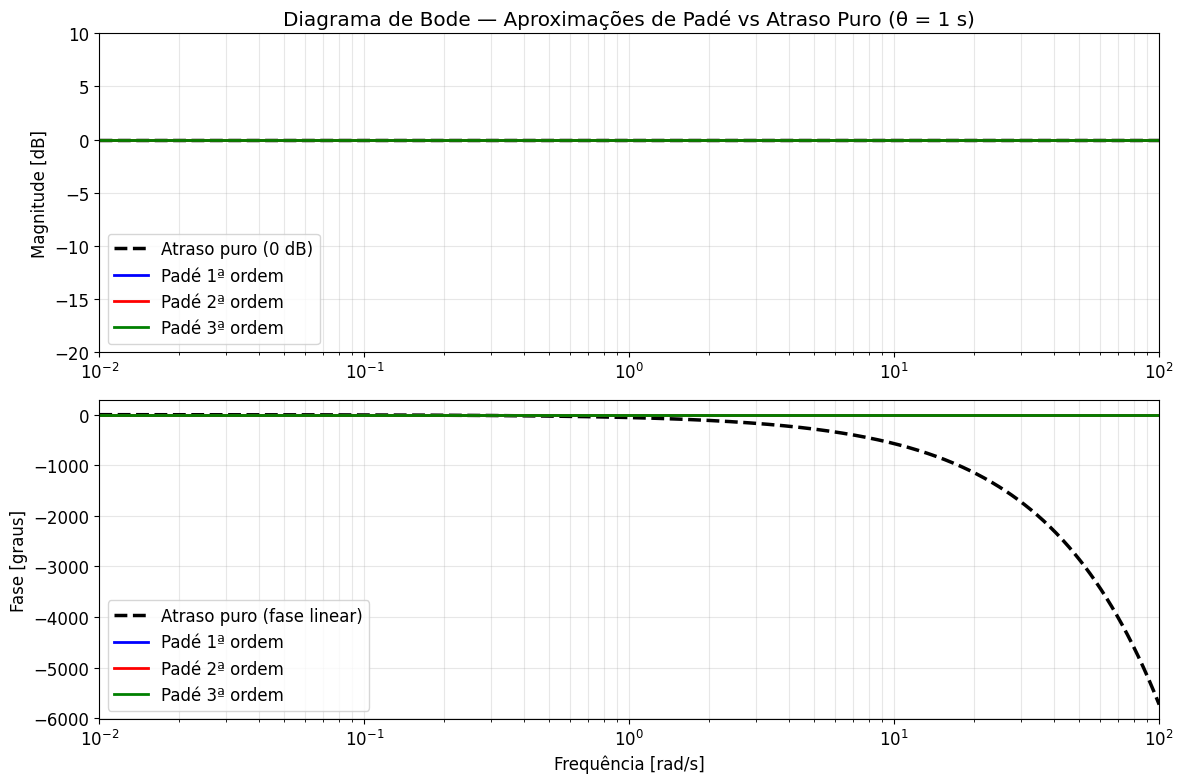

Observações:
  - Em BAIXAS frequências: todas as aproximações são precisas
  - Em ALTAS frequências: as aproximações divergem do atraso puro
  - A magnitude ideal é 0 dB em todas as frequências
  - A fase ideal decresce linearmente (o que aproximações de ordem finita não conseguem reproduzir)
  - Ordens maiores mantêm a precisão em uma faixa de frequência mais ampla


In [10]:
# ==================== Diagrama de Bode — Aproximações de Padé ====================

omega = np.logspace(-2, 2, 1000)

# Resposta em frequência do atraso puro ideal
mag_ideal = np.ones_like(omega)  # |e^(-jωθ)| = 1
phase_ideal = -omega * theta * (180 / np.pi)  # fase em graus

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- Magnitude ---
ax = axes[0]
ax.semilogx(omega, 20*np.log10(mag_ideal), 'k--', linewidth=2.5, label='Atraso puro (0 dB)')

for sys_pade, label, color in [(Pade1_ctrl, 'Padé 1ª ordem', 'b'),
                                (Pade2_ctrl, 'Padé 2ª ordem', 'r'),
                                (Pade3_ctrl, 'Padé 3ª ordem', 'g')]:
    mag, phase, w = ctrl.frequency_response(sys_pade, omega)
    ax.semilogx(w, 20*np.log10(np.abs(mag)), color=color, label=label)

ax.set_ylabel('Magnitude [dB]')
ax.set_title(f'Diagrama de Bode — Aproximações de Padé vs Atraso Puro (θ = {theta} s)')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([omega[0], omega[-1]])
ax.set_ylim([-20, 10])

# --- Fase ---
ax = axes[1]
ax.semilogx(omega, phase_ideal, 'k--', linewidth=2.5, label='Atraso puro (fase linear)')

for sys_pade, label, color in [(Pade1_ctrl, 'Padé 1ª ordem', 'b'),
                                (Pade2_ctrl, 'Padé 2ª ordem', 'r'),
                                (Pade3_ctrl, 'Padé 3ª ordem', 'g')]:
    mag, phase, w = ctrl.frequency_response(sys_pade, omega)
    ax.semilogx(w, np.degrees(np.angle(mag)), color=color, label=label)

ax.set_xlabel('Frequência [rad/s]')
ax.set_ylabel('Fase [graus]')
ax.legend(loc='best')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([omega[0], omega[-1]])

plt.tight_layout()
plt.savefig('figuras/bode_pade.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observações:")
print("  - Em BAIXAS frequências: todas as aproximações são precisas")
print("  - Em ALTAS frequências: as aproximações divergem do atraso puro")
print("  - A magnitude ideal é 0 dB em todas as frequências")
print("  - A fase ideal decresce linearmente (o que aproximações de ordem finita não conseguem reproduzir)")
print("  - Ordens maiores mantêm a precisão em uma faixa de frequência mais ampla")

## 11. Estabilidade em malha fechada

Com realimentação unitária:

$$G_{MF}(s) = \frac{G_1(s) \cdot G_2(s)}{1 + G_1(s) \cdot G_2(s)}$$

Vemos o que acontece com os polos conforme θ aumenta.

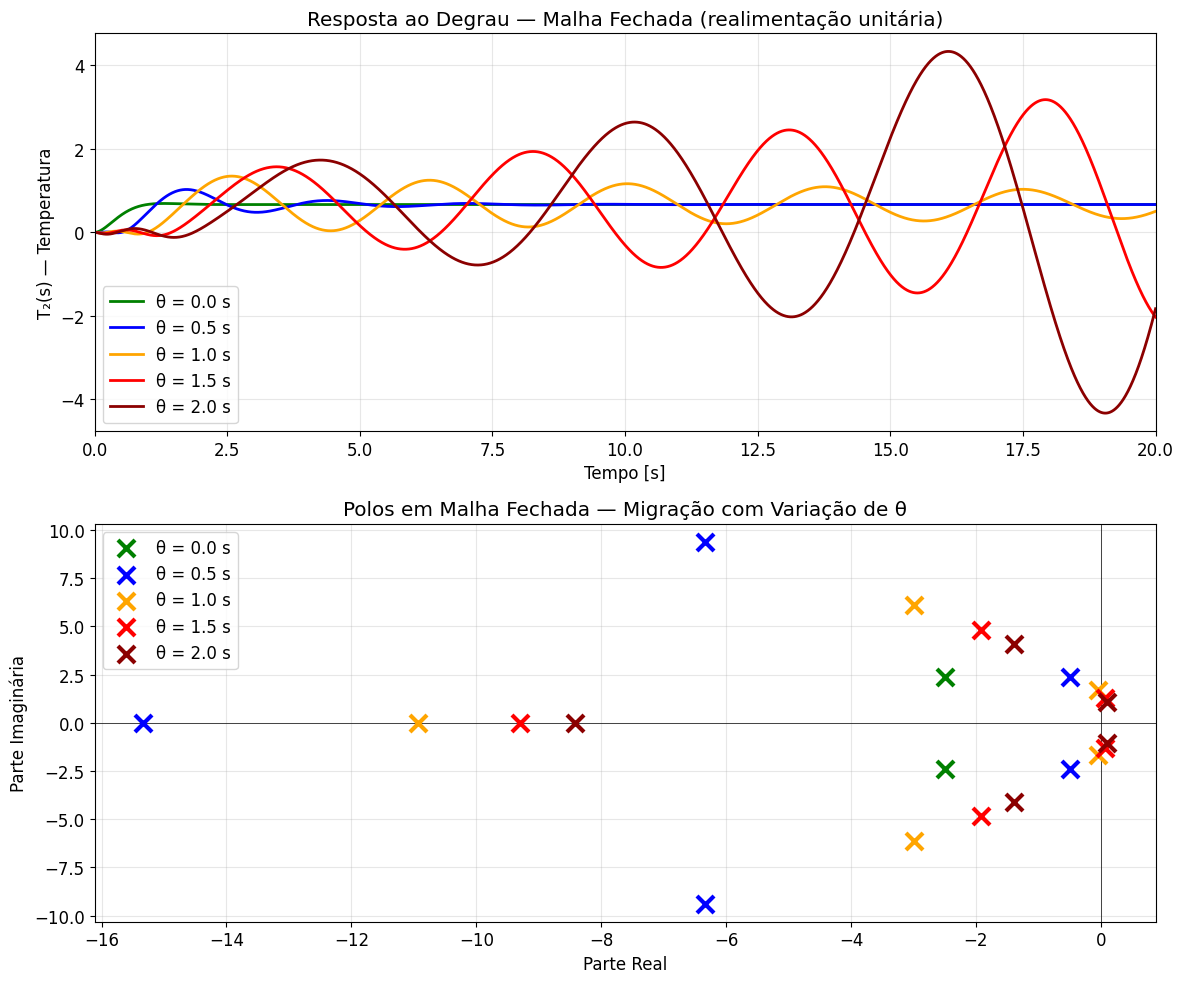


Polos da malha fechada para cada θ:
  θ = 0.0 s: [-2.5+2.39791576j -2.5-2.39791576j]
           ESTÁVEL ✓
  θ = 0.5 s: [-15.3400042 +0.j          -6.33373483+9.37551927j
  -6.33373483-9.37551927j  -0.49626307+2.37064903j
  -0.49626307-2.37064903j]
           ESTÁVEL ✓
  θ = 1.0 s: [-10.93381097+0.j          -2.99128981+6.11414531j
  -2.99128981-6.11414531j  -0.0418047 +1.68549714j
  -0.0418047 -1.68549714j]
           ESTÁVEL ✓
  θ = 1.5 s: [-9.29240228+0.j         -1.92436298+4.83294889j -1.92436298-4.83294889j
  0.07056412+1.3006898j   0.07056412-1.3006898j ]
           INSTÁVEL ✗
  θ = 2.0 s: [-8.4265303 +0.j         -1.39132342+4.10147334j -1.39132342-4.10147334j
  0.10458857+1.06199931j  0.10458857-1.06199931j]
           INSTÁVEL ✗


In [11]:
# ==================== Sistema em Malha Fechada — Variação de θ ====================

theta_values_mf = [0, 0.5, 1.0, 1.5, 2.0]
t = np.linspace(0, 20, 3000)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
colors_mf = ['green', 'blue', 'orange', 'red', 'darkred']

# --- Malha Fechada com Padé 3ª ordem ---
ax = axes[0]
for th, color in zip(theta_values_mf, colors_mf):
    if th == 0:
        G_ma = ctrl.series(G1, G2_sa)
    else:
        num_p, den_p = ctrl.pade(th, 3)
        Pade_approx = ctrl.tf(num_p, den_p)
        G_ma = ctrl.series(G1, G2_sa, Pade_approx)

    G_mf = ctrl.feedback(G_ma, 1)

    try:
        t_r, y_r = ctrl.step_response(G_mf, t)
        ax.plot(t_r, y_r, color=color, linewidth=2, label=f'θ = {th:.1f} s')
    except Exception as e:
        print(f"Erro para θ = {th}: {e}")

ax.set_xlabel('Tempo [s]')
ax.set_ylabel('T₂(s) — Temperatura')
ax.set_title('Resposta ao Degrau — Malha Fechada (realimentação unitária)')
ax.legend(loc='best')
ax.grid(True)
ax.set_xlim([0, 20])

# --- Polos da malha fechada ---
ax = axes[1]
for th, color in zip(theta_values_mf, colors_mf):
    if th == 0:
        G_ma = ctrl.series(G1, G2_sa)
    else:
        num_p, den_p = ctrl.pade(th, 3)
        Pade_approx = ctrl.tf(num_p, den_p)
        G_ma = ctrl.series(G1, G2_sa, Pade_approx)

    G_mf = ctrl.feedback(G_ma, 1)
    poles = G_mf.poles()
    ax.scatter(poles.real, poles.imag, marker='x', color=color, s=150, linewidths=3,
               label=f'θ = {th:.1f} s', zorder=5)

ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('Parte Real')
ax.set_ylabel('Parte Imaginária')
ax.set_title('Polos em Malha Fechada — Migração com Variação de θ')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figuras/malha_fechada_theta.png', dpi=150, bbox_inches='tight')
plt.show()

# Exibir polos
print("\nPolos da malha fechada para cada θ:")
print("="*60)
for th in theta_values_mf:
    if th == 0:
        G_ma = ctrl.series(G1, G2_sa)
    else:
        num_p, den_p = ctrl.pade(th, 3)
        Pade_approx = ctrl.tf(num_p, den_p)
        G_ma = ctrl.series(G1, G2_sa, Pade_approx)
    G_mf = ctrl.feedback(G_ma, 1)
    poles = G_mf.poles()
    estavel = all(p.real < 0 for p in poles)
    print(f"  θ = {th:.1f} s: {poles}")
    print(f"           {'ESTÁVEL ✓' if estavel else 'INSTÁVEL ✗'}")

## 12. Tabela comparativa

Resumo numérico dos resultados.

In [12]:
# ==================== Tabela Comparativa ====================

print("="*80)
print(f"{'TABELA COMPARATIVA — APROXIMAÇÕES DE PADÉ (θ = 1 s)':^80}")
print("="*80)
print(f"{'Propriedade':<30} {'1ª Ordem':<16} {'2ª Ordem':<16} {'3ª Ordem':<16}")
print("-"*80)

for name, sys in [('Nº de Polos', None), ('Nº de Zeros', None)]:
    pass

systems_pade = [Pade1_ctrl, Pade2_ctrl, Pade3_ctrl]

print(f"{'Nº de Polos':<30} {len(Pade1_ctrl.poles()):<16} {len(Pade2_ctrl.poles()):<16} {len(Pade3_ctrl.poles()):<16}")
print(f"{'Nº de Zeros':<30} {len(Pade1_ctrl.zeros()):<16} {len(Pade2_ctrl.zeros()):<16} {len(Pade3_ctrl.zeros()):<16}")
print(f"{'Ganho DC':<30} {ctrl.dcgain(Pade1_ctrl):<16.4f} {ctrl.dcgain(Pade2_ctrl):<16.4f} {ctrl.dcgain(Pade3_ctrl):<16.4f}")
print(f"{'Fase não-mínima?':<30} {'Sim':<16} {'Sim':<16} {'Sim':<16}")

# Comportamento inicial (undershoot/overshoot)
t_curto = np.linspace(0, 0.01, 100)
for n, sys_p in enumerate([Pade1_ctrl, Pade2_ctrl, Pade3_ctrl], 1):
    _, y = ctrl.step_response(sys_p, t_curto)
    if y[1] < 0:
        comportamento = "Undershoot"
    elif y[1] > 1:
        comportamento = "Overshoot"
    else:
        comportamento = "Suave"
    if n == 1:
        print(f"{'Comportamento inicial':<30} ", end="")
    print(f"{comportamento:<16}", end="")
print()
print("="*80)

print("\n" + "="*80)
print(f"{'ESTABILIDADE EM MALHA FECHADA':^80}")
print("="*80)
print(f"{'θ [s]':<10} {'Estável?':<12} {'Polo mais à direita':<30}")
print("-"*80)
for th in [0, 0.5, 1.0, 1.5, 2.0]:
    if th == 0:
        G_ma = ctrl.series(G1, G2_sa)
    else:
        num_p, den_p = ctrl.pade(th, 3)
        G_ma = ctrl.series(G1, G2_sa, ctrl.tf(num_p, den_p))
    G_mf = ctrl.feedback(G_ma, 1)
    poles = G_mf.poles()
    max_real = max(p.real for p in poles)
    estavel = max_real < 0
    print(f"{th:<10.1f} {'Sim ✓' if estavel else 'Não ✗':<12} {max_real:<30.4f}")
print("="*80)

              TABELA COMPARATIVA — APROXIMAÇÕES DE PADÉ (θ = 1 s)               
Propriedade                    1ª Ordem         2ª Ordem         3ª Ordem        
--------------------------------------------------------------------------------
Nº de Polos                    1                2                3               
Nº de Zeros                    1                2                3               
Ganho DC                       1.0000           1.0000           1.0000          
Fase não-mínima?               Sim              Sim              Sim             
Comportamento inicial          Undershoot      Suave           Undershoot      

                         ESTABILIDADE EM MALHA FECHADA                          
θ [s]      Estável?     Polo mais à direita           
--------------------------------------------------------------------------------
0.0        Sim ✓        -2.5000                       
0.5        Sim ✓        -0.4963                       
1.0        Sim ✓    

## 13. Conclusões

Pelos resultados das simulações:

1. Ordens maiores de Padé aproximam melhor o atraso puro, tanto no tempo (degrau) quanto em frequência (Bode).

2. A implementação manual e a `control.pade()` deram resultados iguais — mesmos polos e zeros.

3. Ordens ímpares causam undershoot inicial, pares causam overshoot. Dá para ver nos gráficos da seção 6.

4. Em malha aberta, o atraso só desloca a resposta no tempo. Não muda o valor final nem a forma da curva.

5. Em malha fechada, aumentar θ empurra os polos para a direita no plano complexo. Com θ grande o suficiente, o sistema fica instável.

6. No Bode, as aproximações são boas em baixa frequência e divergem em alta. Mais ordem, mais faixa útil.